# Phase 2 v2 — flexible key_freqs (cum_energy τ=0.90)

Re-train Phase 2 for the **two configs where k=5 is sub-optimal** :

| Config | k=5 captures | cum_t0.90 mean | Verdict |
|---|---|---|---|
| **egd_m0_fast**  | ~40 % of W_L energy | ~11.4 freqs | k=5 misses 6-8 key freqs |
| **muon_m0_fast** | ~28 % of W_L energy | ~17.4 freqs | k=5 misses 12-13 key freqs |

**Strategy** :
1. Reload Phase 1 final `model.pt` → identify per-seed key freqs with `cum_energy(τ=0.90, max_k=25)`
2. Re-train Phase 2 with these **flexible per-seed key_freqs**
3. Save into a **new directory** `runs/phase2_v2_flexkf/` (leaves `phase2_optim/` untouched)
4. Plot Fourier loss + freq mass + sparsity

Same training settings as original Phase 2 : `num_epochs=25_000`, `adaptive_logging=True (factor=5)`, `eval_every=fourier_every=10`.

## Setup

In [19]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch as t
import matplotlib.pyplot as plt
import importlib, pipeline, model, viz_analysis, fourier_metrics
importlib.reload(pipeline); importlib.reload(model)
importlib.reload(viz_analysis); importlib.reload(fourier_metrics)

from model           import Config
from pipeline        import OptimizerSpec, Trainer
from viz_analysis    import (
    load_seeds, compute_grokking_markers, identify_key_freqs,
    plot_curves_band, plot_fourier_losses_band,
    plot_freq_mass_heatmap_per_seed, plot_sparsity,
)
from fourier_metrics import make_fourier_basis

get_ipython().run_line_magic('matplotlib', 'inline')
plt.rcParams.update({'figure.facecolor':'white','figure.dpi':100,'savefig.dpi':200,'font.size':11})
t.manual_seed(0); np.random.seed(0)

ROOT          = Path.cwd()
PHASE1_ROOT   = ROOT / 'runs' / 'phase2_optim'        # ← read-only (existing P1 dirs)
SAVE_ROOT     = ROOT / 'runs' / 'phase2_v2_flexkf'    # ← new dir for v2 results
FIG_DIR       = ROOT / 'figs_phase2_v2'
SAVE_ROOT.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

# ── Shared training settings ────────────────────────────────────────────────
SEEDS            = [0, 1, 2, 3, 4]
NUM_EPOCHS       = 25_000
EVAL_EVERY       = 10
FOURIER_EVERY    = 10
WARMUP_STEPS     = 10
CONVERGED_THRESH = 0.99

# ── Flexible key-freq selection params ──────────────────────────────────────
KF_METHOD = 'cum_energy'
KF_TAU    = 0.90
KF_MAX_K  = 25         # bumped from 20 → avoid clipping on muon_m0_fast

BASE_CONFIG = Config(
    p=113, d_model=128, d_mlp=512, num_heads=4, n_ctx=3,
    act_type='ReLU', frac_train=0.3,
    num_epochs=NUM_EPOCHS, seed=0,
    adaptive_logging=True, adaptive_logging_thresh=0.99, adaptive_logging_factor=5,
)

FILTER_INTERNAL_2D = lambda n, p: p.ndim >= 2 and 'embed' not in n

print(f'Phase 1 read-only : {PHASE1_ROOT}')
print(f'Phase 2 v2 output : {SAVE_ROOT}')
print(f'Selection method  : {KF_METHOD} (τ={KF_TAU}, max_k={KF_MAX_K})')

Phase 1 read-only : /Users/mverest/Desktop/Fourier/Opti_ML/baseline/runs/phase2_optim
Phase 2 v2 output : /Users/mverest/Desktop/Fourier/Opti_ML/baseline/runs/phase2_v2_flexkf
Selection method  : cum_energy (τ=0.9, max_k=25)


## Configs (2 only)

In [20]:
def make_egd_hybrid(lr_egd, wd_egd, momentum_egd):
    return [
        OptimizerSpec(name='egd', lr=lr_egd, weight_decay=wd_egd,
                      param_filter=FILTER_INTERNAL_2D,
                      extra={'momentum': momentum_egd, 'mode': 'svd'}),
        OptimizerSpec(name='adamw', lr=1e-3, weight_decay=1.0, extra={'betas': (0.9, 0.98)}),
    ]

def make_muon_hybrid(lr_muon, wd_muon, momentum_muon):
    return [
        OptimizerSpec(name='muon', lr=lr_muon, weight_decay=wd_muon,
                      param_filter=FILTER_INTERNAL_2D,
                      extra={'momentum': momentum_muon}),
        OptimizerSpec(name='adamw', lr=1e-3, weight_decay=1.0, extra={'betas': (0.9, 0.98)}),
    ]

CONFIGS = {
    'egd_m0_fast': {
        'optimizer': 'EGD',
        'label':     'EGD m=0 fast (lr=0.3, wd=0.1)',
        'specs':     make_egd_hybrid(lr_egd=0.3, wd_egd=0.1, momentum_egd=0.0),
    },
    'muon_m0_fast': {
        'optimizer': 'Muon',
        'label':     'Muon m=0 fast (lr=0.3, wd=0.1)',
        'specs':     make_muon_hybrid(lr_muon=0.3, wd_muon=0.1, momentum_muon=0.0),
    },
}

for name, cfg in CONFIGS.items():
    cfg['phase1_dir'] = PHASE1_ROOT / name           # ← existing P1 dir (read-only)
    cfg['phase2_dir'] = SAVE_ROOT   / name           # ← new P2 v2 dir
    cfg['phase2_dir'].mkdir(parents=True, exist_ok=True)
    if not cfg['phase1_dir'].exists():
        print(f'⚠ Phase 1 dir missing for {name} : {cfg["phase1_dir"]}')

for name, cfg in CONFIGS.items():
    print(f'  {name:15s} : {cfg["label"]}')

  egd_m0_fast     : EGD m=0 fast (lr=0.3, wd=0.1)
  muon_m0_fast    : Muon m=0 fast (lr=0.3, wd=0.1)


## 1 — Identify per-seed key freqs from Phase 1 `model.pt` (cum_energy τ=0.90)

In [21]:
_basis    = make_fourier_basis(BASE_CONFIG).cpu()
_cos_rows = _basis[1::2]
_sin_rows = _basis[2::2]

def load_components(save_root, seeds, p):
    out = {}
    for s in seeds:
        mp = Path(save_root) / f'seed{s}' / 'model.pt'
        if not mp.exists(): continue
        state = t.load(mp, map_location='cpu')
        if isinstance(state, dict) and 'model_state_dict' in state:
            state = state['model_state_dict']
        def _find(suf):
            for k, v in state.items():
                if k.endswith(suf): return v
            return None
        W_E, W_U, W_out = _find('W_E'), _find('W_U'), _find('W_out')
        if W_E is None or W_U is None or W_out is None: continue
        W_E_p = W_E[:, :p].float().cpu()
        W_L   = (W_U[:, :p].float().cpu().T) @ W_out.float().cpu()
        out[s] = {
            'we_cos':     (W_E_p @ _cos_rows.T).norm(dim=0).numpy(),
            'we_sin':     (W_E_p @ _sin_rows.T).norm(dim=0).numpy(),
            'wl_cos':     (_cos_rows @ W_L).norm(dim=1).numpy(),
            'wl_sin':     (_sin_rows @ W_L).norm(dim=1).numpy(),
            '_W_L':       W_L.numpy(),
            '_basis_cos': _cos_rows.numpy(),
            '_basis_sin': _sin_rows.numpy(),
        }
    return out

def check_converged(save_root, seeds, thresh):
    import json
    out = []
    for s in seeds:
        hp = Path(save_root) / f'seed{s}' / 'history.json'
        if not hp.exists(): continue
        h = json.loads(hp.read_text())
        if h.get('test_acc') and h['test_acc'][-1] >= thresh:
            out.append(s)
    return out

rows = []
for name, cfg in CONFIGS.items():
    converged = check_converged(cfg['phase1_dir'], SEEDS, CONVERGED_THRESH)
    print(f'\n═══ {cfg["label"]} — converged seeds : {converged} ═══')
    if not converged:
        print('  ⚠ no converged seed — skip'); continue
    comp = load_components(cfg['phase1_dir'], converged, p=BASE_CONFIG.p)
    kf   = identify_key_freqs(comp, method=KF_METHOD, tau=KF_TAU, max_k=KF_MAX_K, verbose=True)
    cfg['converged']       = converged
    cfg['per_seed_freqs']  = kf['per_seed']
    for s, freqs in kf['per_seed'].items():
        rows.append({'config': name, 'seed': s, 'n_keep': len(freqs), 'freqs': freqs})

print('\n═══ Summary ═══')
display(pd.DataFrame(rows))


═══ EGD m=0 fast (lr=0.3, wd=0.1) — converged seeds : [0, 1, 2, 3, 4] ═══
[identify_key_freqs] method='cum_energy', max_k=25
  seed 0 : 11 key freqs = [1, 8, 14, 31, 33, 35, 40, 42, 51, 52, 55]    (tau=0.9  energy_captured=0.9004)
  seed 1 : 12 key freqs = [6, 14, 17, 24, 26, 28, 29, 33, 37, 44, 48, 49]    (tau=0.9  energy_captured=0.9363)
  seed 2 : 11 key freqs = [3, 7, 9, 14, 15, 22, 26, 27, 45, 47, 55]    (tau=0.9  energy_captured=0.932)
  seed 3 : 12 key freqs = [2, 3, 7, 8, 19, 25, 29, 37, 38, 49, 53, 55]    (tau=0.9  energy_captured=0.9247)
  seed 4 : 11 key freqs = [7, 10, 14, 15, 26, 31, 37, 47, 49, 53, 55]    (tau=0.9  energy_captured=0.9109)

═══ Muon m=0 fast (lr=0.3, wd=0.1) — converged seeds : [0, 1, 2, 3, 4] ═══
[identify_key_freqs] method='cum_energy', max_k=25
  seed 0 : 17 key freqs = [1, 3, 4, 6, 8, 14, 15, 19, 24, 31, 33, 35, 38, 48, 49, 52, 55]    (tau=0.9  energy_captured=0.9278)
  seed 1 : 19 key freqs = [6, 10, 12, 14, 17, 23, 24, 28, 29, 30, 33, 37, 38, 41, 44

,config,seed,n_keep,freqs
0,egd_m0_fast,0,11,"[1, 8, 14, 31, 33, 35, 40, 42, 51, 52, 55]"
1,egd_m0_fast,1,12,"[6, 14, 17, 24, 26, 28, 29, 33, 37, 44, 48, 49]"
2,egd_m0_fast,2,11,"[3, 7, 9, 14, 15, 22, 26, 27, 45, 47, 55]"
3,egd_m0_fast,3,12,"[2, 3, 7, 8, 19, 25, 29, 37, 38, 49, 53, 55]"
4,egd_m0_fast,4,11,"[7, 10, 14, 15, 26, 31, 37, 47, 49, 53, 55]"
5,muon_m0_fast,0,17,"[1, 3, 4, 6, 8, 14, 15, 19, 24, 31, 33, 35, 38..."
6,muon_m0_fast,1,19,"[6, 10, 12, 14, 17, 23, 24, 28, 29, 30, 33, 37..."
7,muon_m0_fast,2,17,"[2, 3, 6, 7, 15, 16, 25, 26, 27, 35, 36, 38, 4..."
8,muon_m0_fast,3,17,"[3, 5, 7, 8, 10, 14, 16, 25, 29, 31, 35, 36, 3..."
9,muon_m0_fast,4,17,"[1, 3, 7, 9, 10, 14, 15, 20, 26, 28, 31, 32, 3..."


## 2 — Train Phase 2 v2 with the flexible per-seed key_freqs (resume-aware)

Trains 1 seed at a time, skipping seeds already done. Saves to `runs/phase2_v2_flexkf/{name}/seed{s}/`.

In [22]:
for name, cfg in CONFIGS.items():
    per_seed_freqs = cfg.get('per_seed_freqs', {})
    if not per_seed_freqs:
        print(f'\n⚠ {name} : no per_seed_freqs — skip'); continue
    print(f'\n═══ Phase 2 v2 — {cfg["label"]} — flexible per-seed key_freqs ═══')
    for s in sorted(per_seed_freqs.keys()):
        seed_dir = cfg['phase2_dir'] / f'seed{s}'
        if (seed_dir / 'history.json').exists():
            print(f'  seed {s} ✓ already done — skip'); continue
        seed_kf = per_seed_freqs[s]
        print(f'  → seed {s} : training with {len(seed_kf)} key_freqs = {seed_kf}')
        trainer = Trainer(
            BASE_CONFIG, cfg['specs'],
            seed=s, label=f'{name}_p2v2_seed{s}',
            eval_every=EVAL_EVERY,
            fourier_every=FOURIER_EVERY,
            fixed_key_freqs=seed_kf,
            warmup_steps=WARMUP_STEPS,
            verbose_every=5_000, verbose_build=False,
        )
        trainer.fit()
        trainer.save_run(str(seed_dir))


═══ Phase 2 v2 — EGD m=0 fast (lr=0.3, wd=0.1) — flexible per-seed key_freqs ═══
  seed 0 ✓ already done — skip
  seed 1 ✓ already done — skip
  seed 2 ✓ already done — skip
  seed 3 ✓ already done — skip
  seed 4 ✓ already done — skip

═══ Phase 2 v2 — Muon m=0 fast (lr=0.3, wd=0.1) — flexible per-seed key_freqs ═══
  seed 0 ✓ already done — skip
  seed 1 ✓ already done — skip
  seed 2 ✓ already done — skip
  seed 3 ✓ already done — skip
  seed 4 ✓ already done — skip


## 3 — Reload + Fourier plots (loss + freq mass + sparsity)


═══ EGD m=0 fast (lr=0.3, wd=0.1) — Phase 2 v2 (n=5 seeds) ═══
  mem=60.0   circuit=600.0   grok=190.0


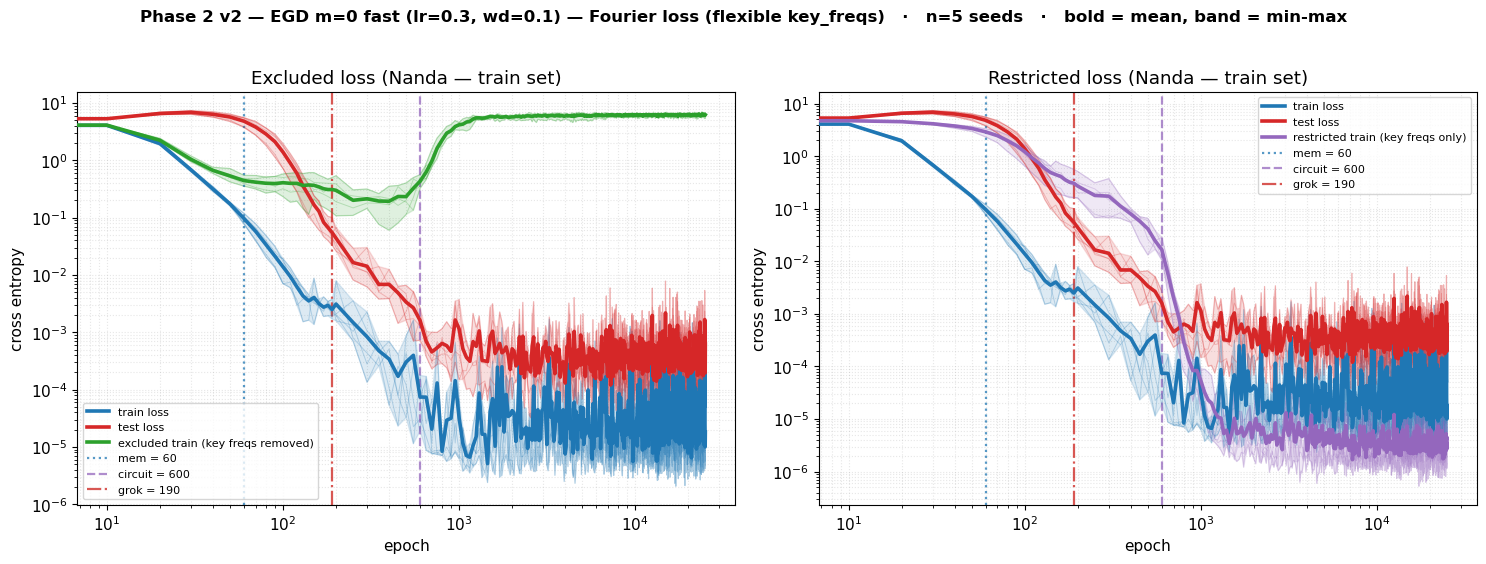

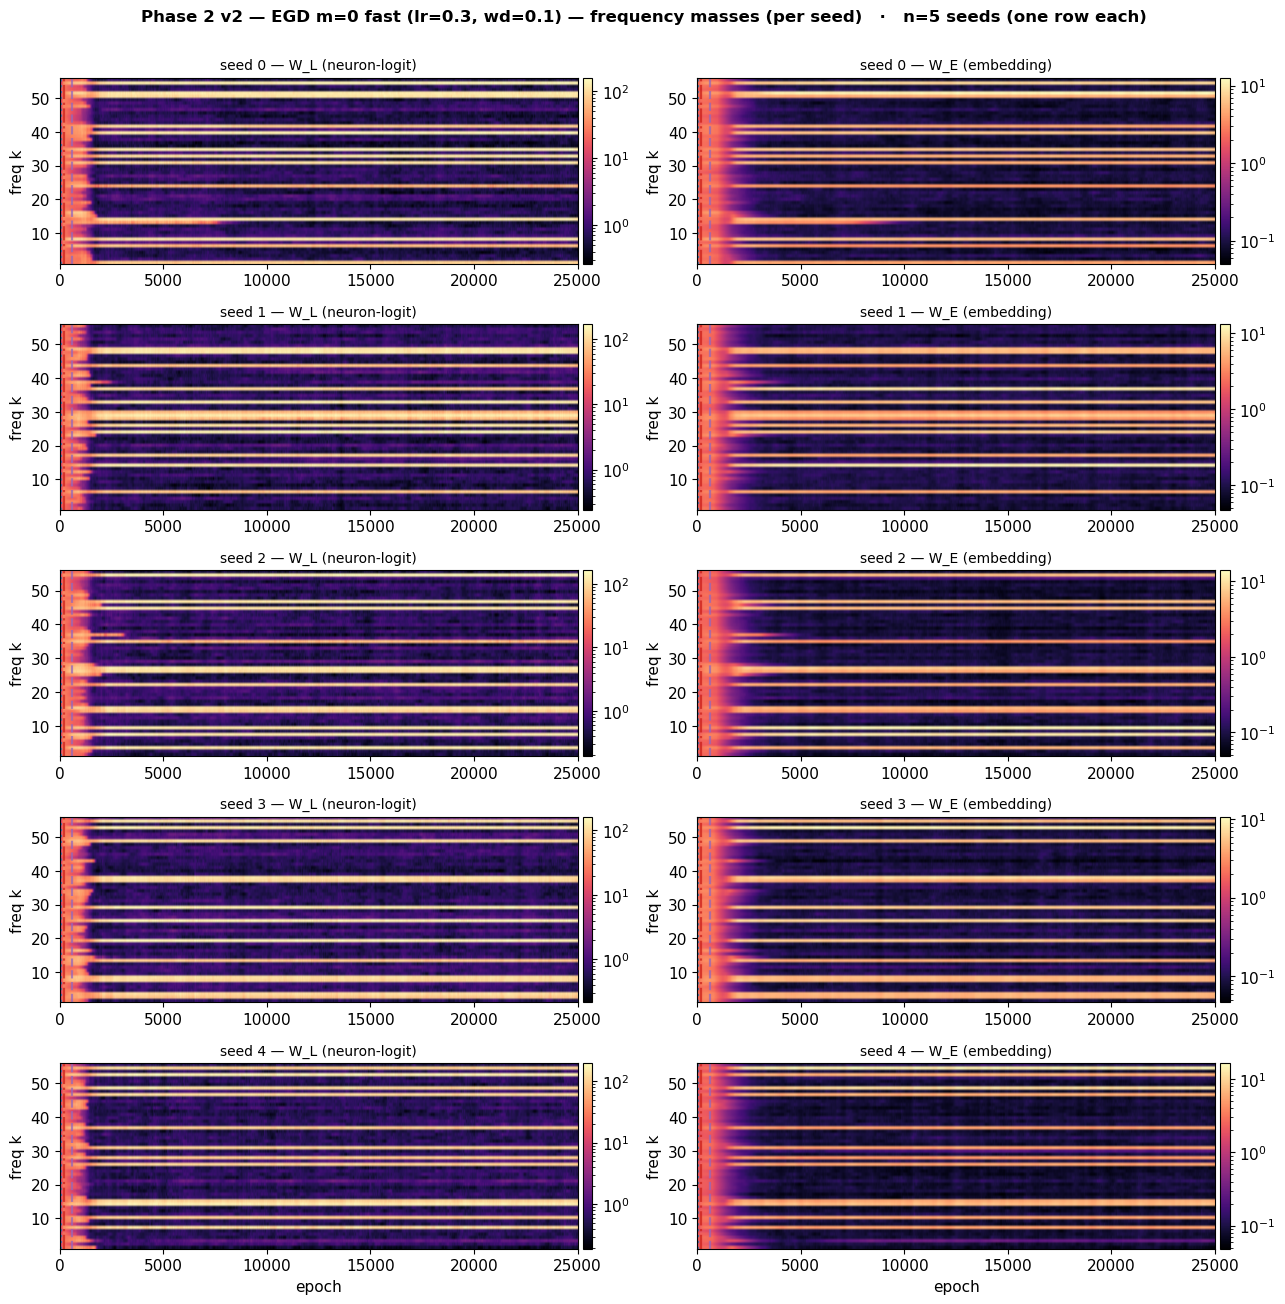

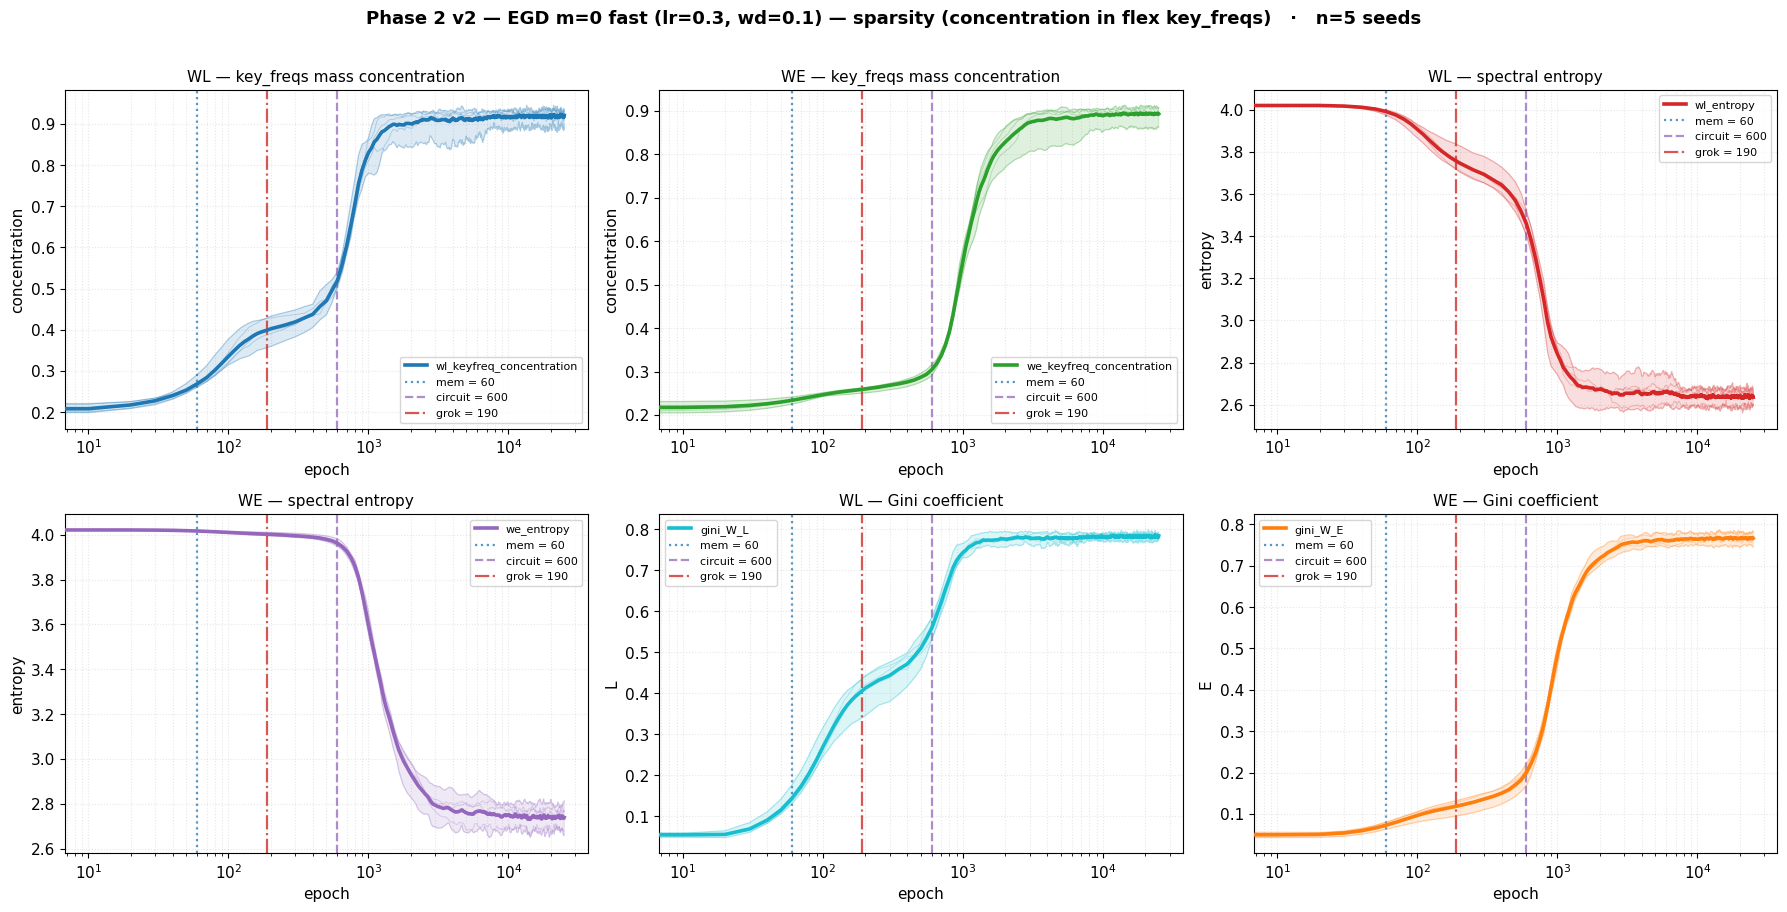


═══ Muon m=0 fast (lr=0.3, wd=0.1) — Phase 2 v2 (n=5 seeds) ═══
  mem=50.0   circuit=120.0   grok=170.0


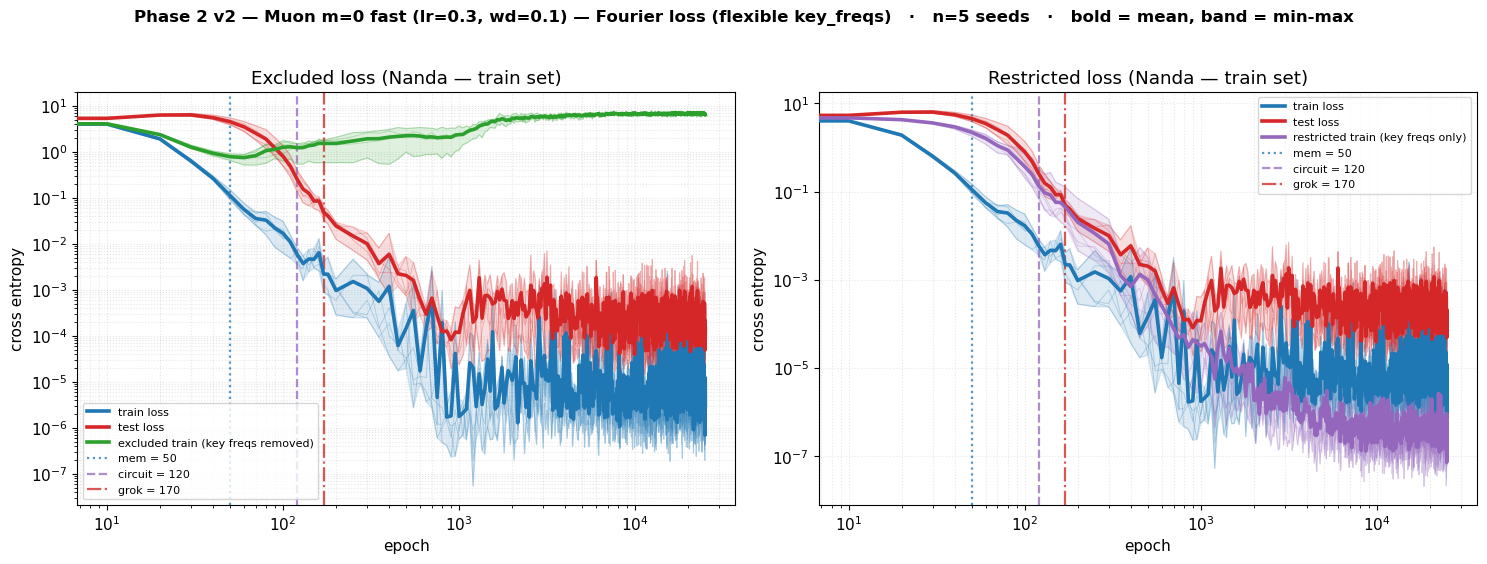

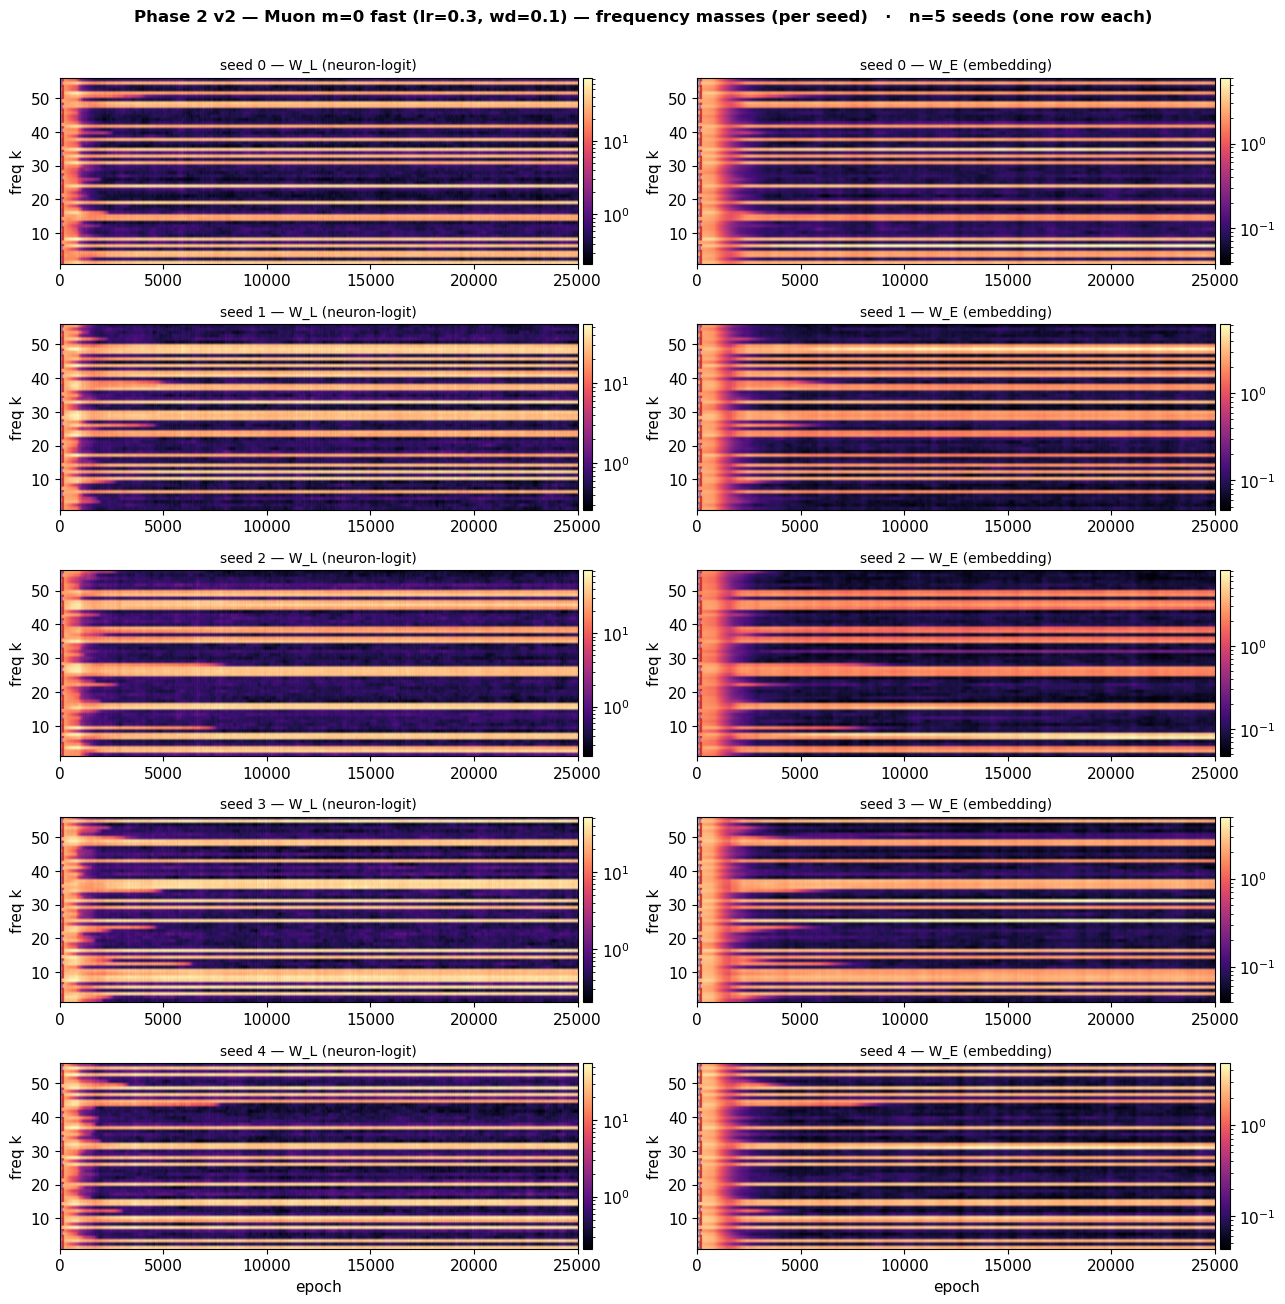

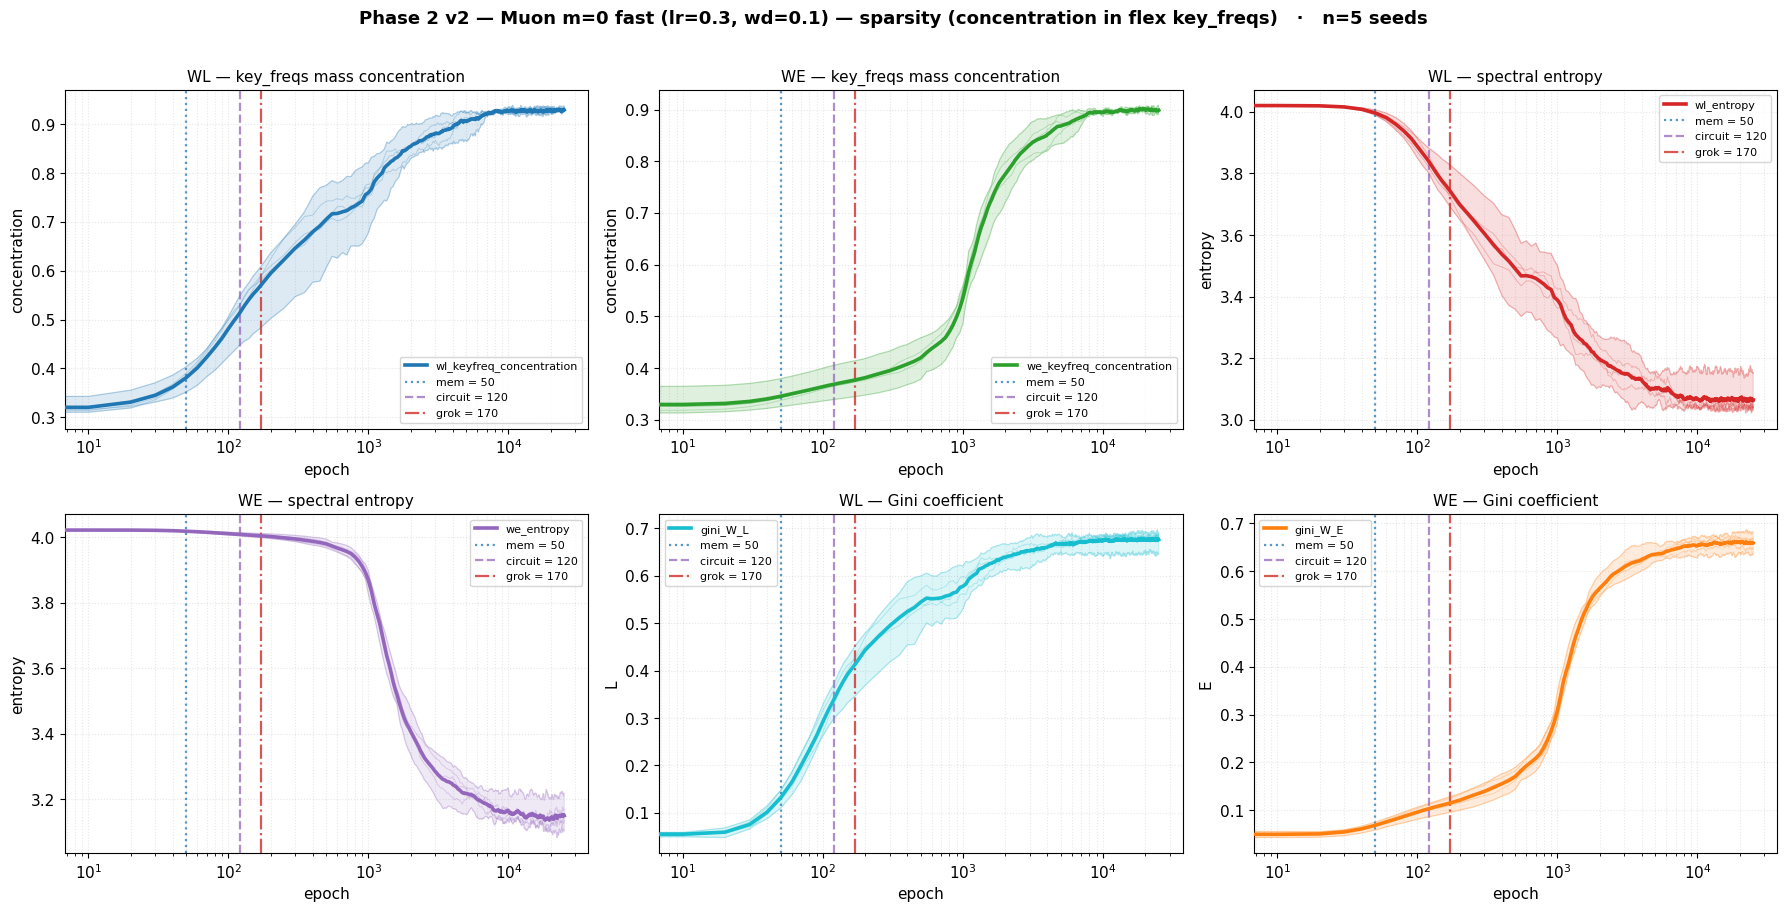

In [23]:
for name, cfg in CONFIGS.items():
    if not cfg.get('per_seed_freqs'): continue
    seeds_to_reload = sorted(cfg['per_seed_freqs'].keys())
    runs, _ = load_seeds(cfg['phase2_dir'], seeds_to_reload)
    if not runs:
        print(f'  ⚠ {name} : no runs loaded — skip plots'); continue
    cfg['runs_2']    = runs
    # circuit_key=None → auto-detects wl_keyfreq_concentration when fixed key_freqs are used
    cfg['markers_2'] = compute_grokking_markers(runs)

    print(f'\n═══ {cfg["label"]} — Phase 2 v2 (n={len(runs)} seeds) ═══')
    m = cfg['markers_2']
    print(f'  mem={m["mem"]}   circuit={m["circuit"]}   grok={m["grok"]}')

    plot_fourier_losses_band(
        runs, title=f'Phase 2 v2 — {cfg["label"]} — Fourier loss (flexible key_freqs)',
        markers=m, save_path=FIG_DIR / f'p2v2_{name}_fourier_loss.png',
    )
    # Per-seed heatmap grid (no averaging across seeds)
    plot_freq_mass_heatmap_per_seed(
        runs, title=f'Phase 2 v2 — {cfg["label"]} — frequency masses (per seed)',
        markers=m, save_path=FIG_DIR / f'p2v2_{name}_freq_masses_per_seed.png',
    )
    plot_sparsity(
        runs, title=f'Phase 2 v2 — {cfg["label"]} — sparsity (concentration in flex key_freqs)',
        markers=m, save_path=FIG_DIR / f'p2v2_{name}_sparsity.png',
    )

## 4 — Comparison v1 (k=5) vs v2 (flexible) — quick numeric summary

Reads both `runs/phase2_optim/{name}/` (v1, k=5) and `runs/phase2_v2_flexkf/{name}/` (v2, flex)
to compare final `wl_keyfreq_concentration` and other key metrics.

In [24]:
import json

def _final_metric(history, key, default=None):
    v = history.get(key)
    if not v: return default
    return v[-1] if isinstance(v, list) else v

comp_rows = []
for name, cfg in CONFIGS.items():
    v1_dir = PHASE1_ROOT / f'{name}_fixedkf'      # ← v1 used `{name}_fixedkf` suffix
    v2_dir = cfg['phase2_dir']
    for s in SEEDS:
        row = {'config': name, 'seed': s}
        for version, dir_path in [('v1 (k=5)', v1_dir), ('v2 (flex)', v2_dir)]:
            hp = dir_path / f'seed{s}' / 'history.json'
            if not hp.exists():
                row[f'{version} wl_conc']      = None
                row[f'{version} restr_train']  = None
                row[f'{version} n_keys']       = None
                continue
            h  = json.loads(hp.read_text())
            kf = h.get('key_freqs')
            if isinstance(kf, list) and len(kf) > 0 and isinstance(kf[0], list):
                kf = kf[-1]
            row[f'{version} wl_conc']     = round(_final_metric(h, 'wl_keyfreq_concentration', np.nan), 3)
            row[f'{version} restr_train'] = round(_final_metric(h, 'restricted_loss_train', np.nan), 4)
            row[f'{version} n_keys']      = len(kf) if isinstance(kf, list) else None
        comp_rows.append(row)

df_cmp = pd.DataFrame(comp_rows)
print('═══ Comparison v1 (k=5) vs v2 (flexible cum_t0.90) — final values ═══')
with pd.option_context('display.max_colwidth', None):
    display(df_cmp)

print('\nExpected pattern :')
print('  • wl_conc      : higher in v2 (key freq set captures more of W_L energy)')
print('  • restr_train  : closer to train_loss in v2 (more freqs → better train reconstruction)')
print('  • n_keys       : 5 for v1, larger (and seed-dependent) for v2')

═══ Comparison v1 (k=5) vs v2 (flexible cum_t0.90) — final values ═══


,config,seed,v1 (k=5) wl_conc,v1 (k=5) restr_train,v1 (k=5) n_keys,v2 (flex) wl_conc,v2 (flex) restr_train,v2 (flex) n_keys
0,egd_m0_fast,0,0.464,0.1889,5,0.900,0.0,11
1,egd_m0_fast,1,0.483,0.2229,5,0.936,0.0,12
2,egd_m0_fast,2,0.475,0.0874,5,0.932,0.0,11
3,egd_m0_fast,3,0.454,0.1228,5,0.925,0.0,12
4,egd_m0_fast,4,0.466,0.4331,5,0.911,0.0,11
5,muon_m0_fast,0,0.328,0.3826,5,0.928,0.0,17
6,muon_m0_fast,1,0.299,0.5182,5,0.930,0.0,19
7,muon_m0_fast,2,0.347,0.2996,5,0.925,0.0,17
8,muon_m0_fast,3,0.315,0.3575,5,0.929,0.0,17
9,muon_m0_fast,4,0.322,0.3665,5,0.935,0.0,17



Expected pattern :
  • wl_conc      : higher in v2 (key freq set captures more of W_L energy)
  • restr_train  : closer to train_loss in v2 (more freqs → better train reconstruction)
  • n_keys       : 5 for v1, larger (and seed-dependent) for v2
